# Miscellaneous Analysis

This notebook explores additional aspects of the Olist e-commerce dataset using PostgreSQL.

The analysis focuses on:

- Orders with low payment values
- Payment method frequency
- Unique customer and seller identifiers
- Freight value distribution
- Product category translations

All analytical calculations are performed in SQL, while Python is used for data retrieval and visualization.

In [1]:
import getpass
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

password = getpass.getpass("PostgreSQL password: ")

connection_url = URL.create(
    "postgresql+psycopg2",
    username="laraolgun",
    password=password,
    host="localhost",
    database="olist"
)

engine = create_engine(connection_url)

print("Connected to PostgreSQL: olist")

Connected to PostgreSQL: olist


## 1. Orders with Payment Value Below 10

In [2]:
query = """
SELECT
    COUNT(*) AS orders_payment_value_less_than_10
FROM orders o
WHERE EXISTS (
    SELECT 1
    FROM order_payments op
    WHERE op.order_id = o.order_id
      AND op.payment_value < 10
);
"""

df_low_payment_orders = pd.read_sql_query(query, engine)

df_low_payment_orders

,orders_payment_value_less_than_10
0,958


## 2. Payment Method Frequency

In [3]:
query = """
SELECT
    payment_type,
    COUNT(*) AS payment_frequency
FROM order_payments
GROUP BY payment_type
ORDER BY payment_frequency DESC;
"""

df_payment_methods = pd.read_sql_query(query, engine)

df_payment_methods

,payment_type,payment_frequency
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


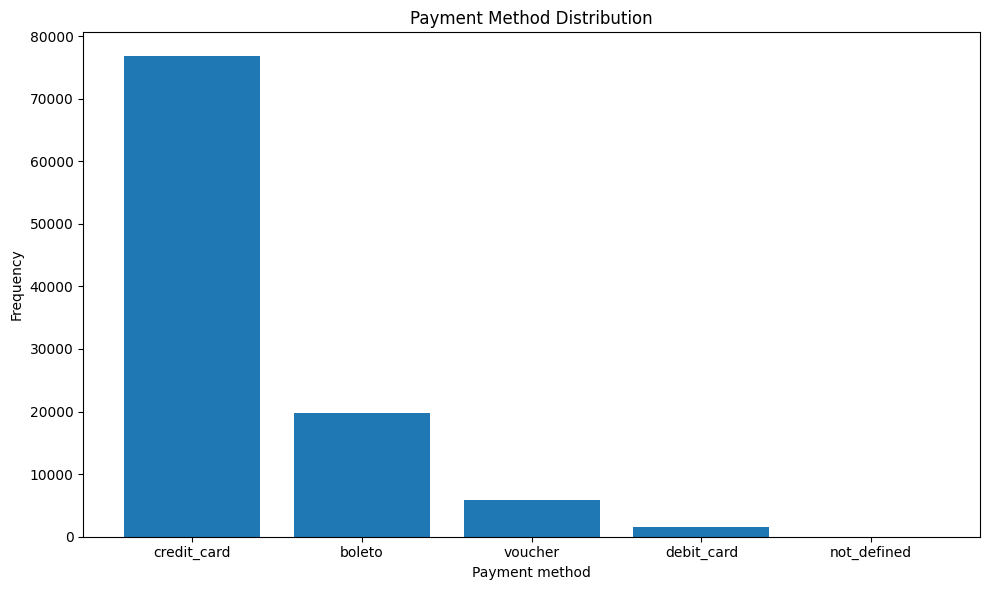

In [4]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_payment_methods["payment_type"],
    df_payment_methods["payment_frequency"]
)

plt.xlabel("Payment method")
plt.ylabel("Frequency")
plt.title("Payment Method Distribution")

plt.tight_layout()
plt.show()

## 3. Total Unique Customer and Seller IDs

In [5]:
query = """
SELECT
    COUNT(*) AS total_unique_ids
FROM (
    SELECT customer_unique_id AS id
    FROM customers

    UNION

    SELECT seller_id::text AS id
    FROM sellers
) AS ids;
"""

df_total_ids = pd.read_sql_query(query, engine)

df_total_ids

,total_unique_ids
0,99191


## 4. Freight Value Distribution

In [6]:
query = """
SELECT
    CASE
        WHEN freight_value = 0 THEN 'FREE'
        WHEN freight_value < 10 THEN 'VERY LOW'
        WHEN freight_value < 100 THEN 'LOW'
        WHEN freight_value < 200 THEN 'MEDIUM'
        ELSE 'HIGH'
    END AS freight_category,
    COUNT(*) AS frequency
FROM order_items
GROUP BY freight_category
ORDER BY frequency DESC;
"""

df_freight_distribution = pd.read_sql_query(query, engine)

df_freight_distribution

,freight_category,frequency
0,LOW,96133
1,VERY LOW,15463
2,MEDIUM,601
3,FREE,383
4,HIGH,70


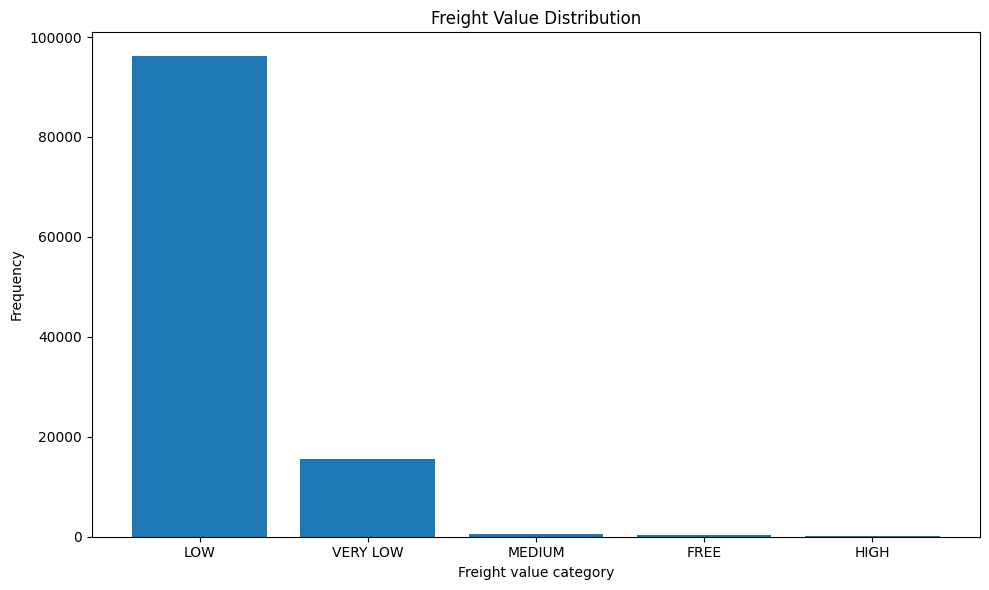

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_freight_distribution["freight_category"],
    df_freight_distribution["frequency"]
)

plt.xlabel("Freight value category")
plt.ylabel("Frequency")
plt.title("Freight Value Distribution")

plt.tight_layout()
plt.show()

## 5. Product Category Translation

In [8]:
query = """
SELECT
    p.product_category,
    pt.category_translation
FROM (
    SELECT DISTINCT product_category
    FROM products
    WHERE product_category IS NOT NULL
) p
LEFT JOIN product_translation pt
    ON p.product_category = pt.category;
"""

df_product_translation = pd.read_sql_query(query, engine)

df_product_translation

,product_category,category_translation
0,climatizacao,air_conditioning
1,livros_importados,books_imported
2,artigos_de_natal,christmas_supplies
3,livros_tecnicos,books_technical
4,ferramentas_jardim,garden_tools
...,...,...
68,eletrodomesticos_2,home_appliances_2
69,cds_dvds_musicais,cds_dvds_musicals
70,fashion_bolsas_e_acessorios,fashion_bags_accessories
71,construcao_ferramentas_seguranca,construction_tools_safety


In [9]:
engine.dispose()